In [ ]:
################################
##                            ##
##          INSTALL           ##
##                            ##
################################

In [ ]:
!pip install pmdarima numpy==1.26.4
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [ ]:
############################
##          DATA          ##
############################

In [ ]:
# ---------------------------
# กำหนดค่า seed ให้เหมือนกันทุกครั้ง
# ---------------------------
import tensorflow as tf
import random
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

            Price
Date             
2022-01-03  16.60
2022-01-04  16.91
2022-01-05  19.73
2022-01-06  19.61
2022-01-07  18.76


<Figure size 1000x600 with 0 Axes>

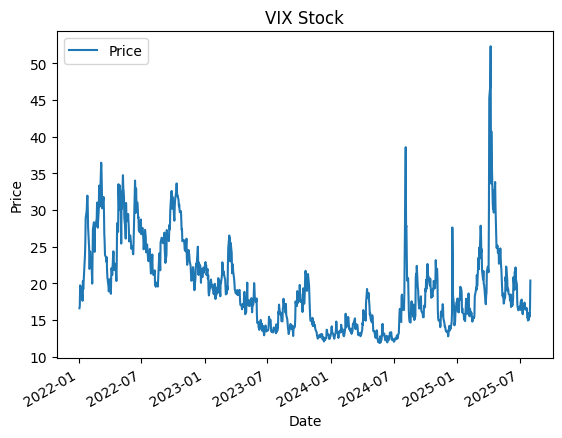

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูล
url = "CBOE Volatility Index Historical Data.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)
df = df.sort_index()

# ดูข้อมูลเบื้องต้น
print(df.head())

# พล็อตข้อมูล
plt.figure(figsize=(10, 6))
df.plot()
plt.title("VIX Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

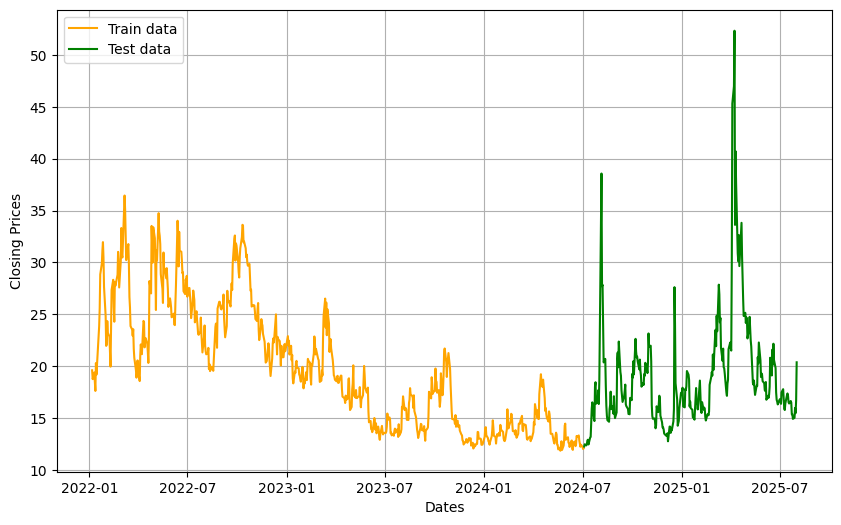

In [ ]:
train_data, test_data = df['Price'][3:int(len(df['Price'])*0.7)] , df['Price'][int(len(df['Price'])*0.7):]
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_data, 'orange', label='Train data')
plt.plot(test_data, 'green', label='Test data')
plt.legend()

In [ ]:
#---------------
# คำนวณ error
#---------------

def cal_error(train , train_pred , test , test_pred):
  from math import sqrt
  import numpy as np
  from sklearn.metrics import mean_squared_error, mean_absolute_error
  # ---------------------------
  # คำนวณค่า RMSE, MAE, MAPE
  # ---------------------------
  train_rmse = sqrt(mean_squared_error(train, train_pred))
  test_rmse = sqrt(mean_squared_error(test, test_pred))

  train_mae = mean_absolute_error(train, train_pred)
  test_mae = mean_absolute_error(test, test_pred)

  train_mape = np.mean(np.abs((train - train_pred) / train)) * 100
  test_mape = np.mean(np.abs((test - test_pred) / test)) * 100

  print(f"Train --> RMSE: {train_rmse:.2f}, MAE: {train_mae:.2f}, MAPE: {train_mape:.2f}%")
  print(f"Test --> RMSE: {test_rmse:.2f}, MAE: {test_mae:.2f}, MAPE: {test_mape:.2f}%")

In [ ]:
# สร้าง formatter สำหรับปี พ.ศ.
def format_thai_date(x, pos=None):
    date = mdates.num2date(x)
    thai_year = date.year + 543
    return f"{date.day:02d}/{date.month:02d}/{thai_year}"

In [ ]:
##################################
##                              ##
##          Box-Jenkins         ##
##                              ##
##################################

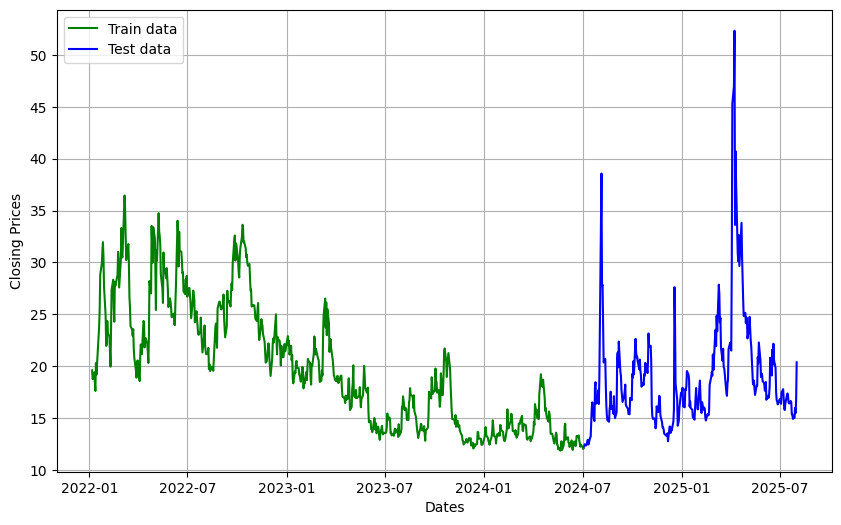

In [ ]:
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_data , 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

Mode = additive
  Seasonal variance / Residual variance → used for strength check


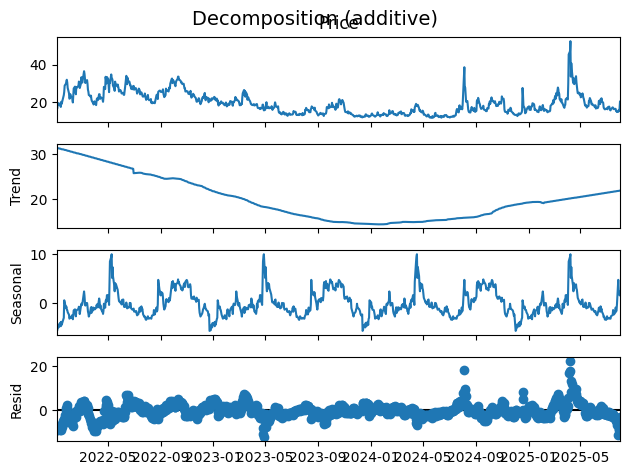

Strength (additive): 0.38447622411879245


In [ ]:
#---------------------------------
#   ทดสอบ Trend , Seasonal
#---------------------------------

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


def decompose_and_plot(series, mode, period=252):
    res = seasonal_decompose(series, model=mode, period=period, extrapolate_trend='freq')
    print(f"Mode = {mode}")
    print("  Seasonal variance / Residual variance → used for strength check")
    res.plot()
    plt.suptitle(f"Decomposition ({mode})", fontsize=14)
    plt.show()
    return res

# Drop missing values from MSFT_close
df_cleaned = df['Price'].dropna()

# ทดลองทั้งสองแบบ
res_add = decompose_and_plot(df_cleaned, mode='additive', period=252)

# คำนวณ seasonal strength แบบ additive
def seasonal_strength(res):
    resid = res.resid.dropna()
    seasonal = res.seasonal.dropna()
    denom = (resid + seasonal).var()
    if denom == 0:
        return np.nan
    return 1 - (resid.var() / denom)

print("Strength (additive):", seasonal_strength(res_add))

#--------------------------------------
#  ใช้วิธี Additive
#--------------------------------------

result = seasonal_decompose(df_cleaned, model='additive', period=252)

In [ ]:
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress

df_cal = df_cleaned

# ลองเช็ค
for d in range(2):
  t = np.arange(len(df_cal))
  result = adfuller(df_cal)
  result_kpss = kpss(df_cal, regression = 'ct')
  result_linear = linregress(t, df_cal)

  if result[1] <= 0.05:
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("KPSS Statistic:", result_kpss[0])
    print("p-value:", result_kpss[1])
    print("Slope:", result_linear[0])
    print("p-value:", result_linear[3])
    print('Stationary')
    print('d =',d)
    break
  else:
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("KPSS Statistic:", result_kpss[0])
    print("p-value:", result_kpss[1])
    print("Slope:", result_linear[0])
    print("p-value:", result_linear[3])
    df_cal = np.log(df_cleaned)
    df_cal = df_cal.diff().dropna()
    print('Non stationary')

ADF Statistic: -4.1603946101893365
p-value: 0.0007683369711586178
KPSS Statistic: 0.7137454688308019
p-value: 0.01
Slope: -0.009544005440271067
p-value: 3.081716900021137e-45
Stationary
d = 0


/tmp/ipython-input-3638192293.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_kpss = kpss(df_cal, regression = 'ct')


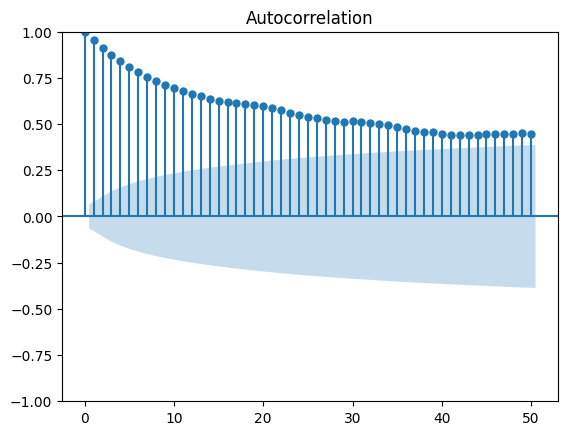

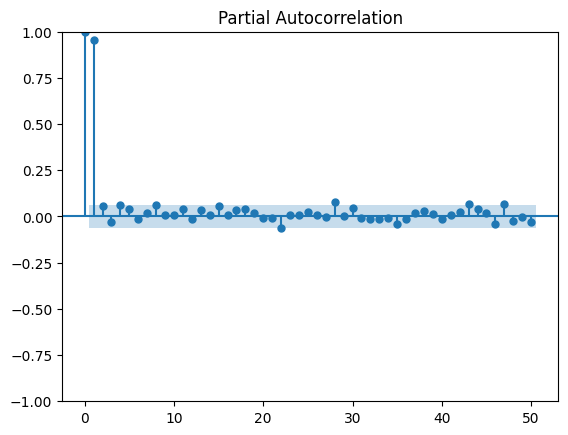

In [ ]:
#-------------------------
#   กราฟ ACF , PACF
#-------------------------

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['Price'],lags=50)
plot_pacf(df['Price'],lags=50)
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=5744.046, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=4897.428, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2169.930, Time=0.06 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2169.360, Time=0.30 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=2168.614, Time=0.38 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=1.37 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2168.700, Time=0.19 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=2163.191, Time=0.84 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=2161.979, Time=0.77 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=2163.123, Time=0.29 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=2163.165, Time=0.29 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2163.381, T

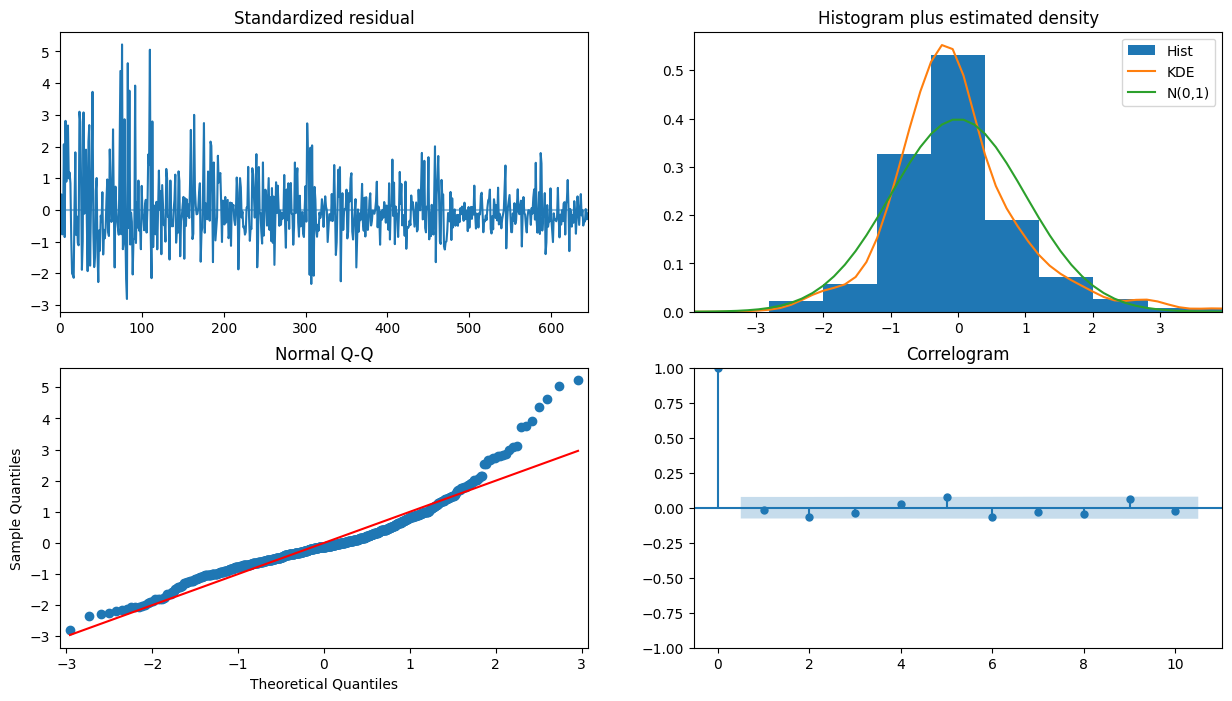

In [ ]:
from pmdarima import auto_arima
model_autoARIMA = auto_arima(train_data, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0,
                      D=0,
                      trace=True,
                      error_action='ignore',
                      suppress_warnings=True,
                      stepwise=True)
print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(15,8))
plt.show()

In [ ]:
model = ARIMA(train_data, order=(1,0,0))
fitted = model.fit()
print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  646
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1077.707
Date:                Sun, 02 Nov 2025   AIC                           2161.414
Time:                        05:18:32   BIC                           2174.826
Sample:                             0   HQIC                          2166.617
                                - 646                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.2760      3.025      6.372      0.000      13.347      25.205
ar.L1          0.9765      0.009    104.715      0.000       0.958       0.995
sigma2         1.6387      0.061     26.743      0.0

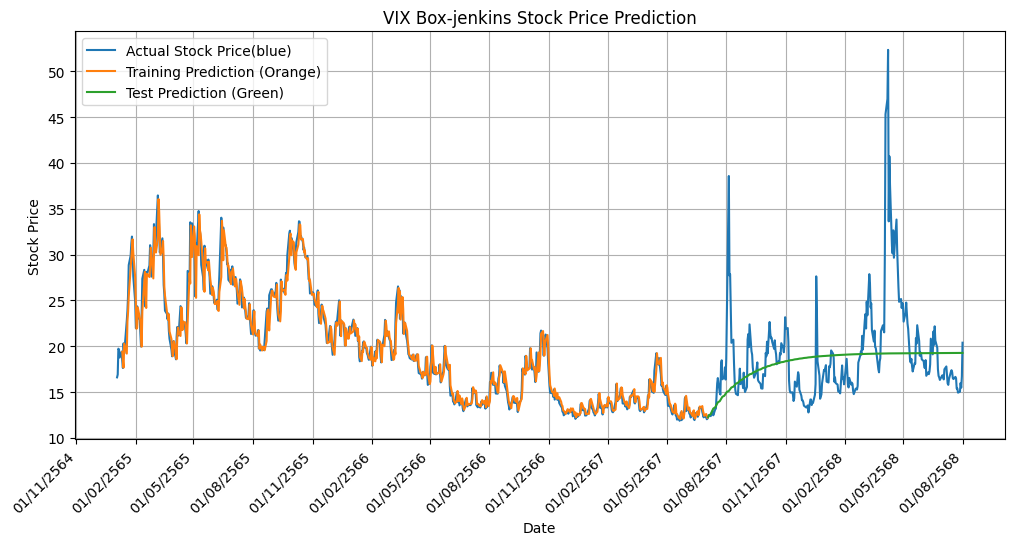

In [ ]:
# Forecast
# Only get the forecast values as retrieving se and conf is causing issues in this environment
fc = fitted.forecast(len(test_data))

# 4) ทำนายในชุด Train
#    ใช้ start/end ให้ครอบคลุม train index
train_pred = fitted.predict(start=train_data.index[3], end=train_data.index[-1], typ='levels')

# 5) ทำนายในชุด Test
test_pred = pd.Series(fc.values, index=test_data.index)

# ----------------------------------------------------
# Plot รวม train/test
# ----------------------------------------------------
plt.figure(figsize=(12,6))
plt.plot(df['Price'],label='Actual Stock Price(blue)')
plt.plot(train_pred, label='Training Prediction (Orange)')
plt.plot(test_pred, label='Test Prediction (Green)')

plt.title('VIX Box-jenkins Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)

# ---------------------------
# Format วันที่เป็น วัน/เดือน/ปี
# ---------------------------
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)

plt.show()

In [ ]:
print(test_pred[-30:])

Date
2025-06-23    19.257201
2025-06-24    19.257643
2025-06-25    19.258074
2025-06-26    19.258495
2025-06-27    19.258907
2025-06-30    19.259308
2025-07-01    19.259700
2025-07-02    19.260083
2025-07-03    19.260457
2025-07-04    19.260822
2025-07-07    19.261179
2025-07-08    19.261527
2025-07-09    19.261867
2025-07-10    19.262199
2025-07-11    19.262523
2025-07-14    19.262840
2025-07-15    19.263149
2025-07-16    19.263451
2025-07-17    19.263745
2025-07-18    19.264033
2025-07-21    19.264314
2025-07-22    19.264589
2025-07-23    19.264857
2025-07-24    19.265118
2025-07-25    19.265374
2025-07-28    19.265623
2025-07-29    19.265867
2025-07-30    19.266105
2025-07-31    19.266337
2025-08-01    19.266564
dtype: float64


In [ ]:
cal_error(train_data[3:],train_pred,test_data,test_pred)

Train --> RMSE: 1.28, MAE: 0.90, MAPE: 4.33%
Test --> RMSE: 5.36, MAE: 3.38, MAPE: 16.12%


In [ ]:
# --- Function to Prepare Dataset for ANN, LSTM ---
# convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    # Ensure there are enough data points to create at least one sequence
    if len(dataset) > look_back:
        # The loop runs up to the point where the last sequence ends one step before the end of the dataset
        for i in range(len(dataset) - look_back):
            # X is the sequence of 'look_back' previous values
            a = dataset[i:(i + look_back), 0]
            # Y is the value immediately following the sequence Y
            dataX.append(a)
            dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:
##################################
##                              ##
##            LSTM              ##
##                              ##
##################################

In [ ]:
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Input # Import Input layer
import time #helper libraries

Training model... This might take a moment.
Model training completed in 98.06 seconds.
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Test predictions exported to lstm_result.csv


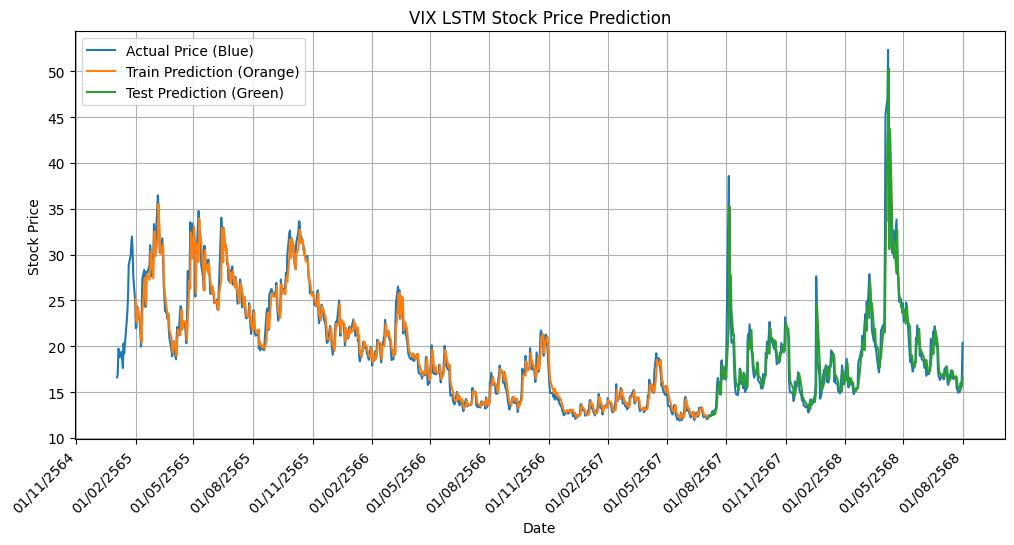

In [ ]:
# --- Configuration ---
look_back = 20 # Reduced Timestep for LSTM to ensure test data availability

# --- Data Loading and Preprocessing ---

# load the dataset
try:
    df = read_csv(url)
except FileNotFoundError:
    print(f"Error: File not found at {url}. Please ensure the file is uploaded.")
    exit()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df = df.sort_values(by=df.columns[0], ascending=True).reset_index(drop=True)

# take close price column (index 1 for 'Price' in this file structure)
# Assuming 'Price' is the 2nd column (index 1)
all_y = df[df.columns[1]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# split into train and test sets, 70% training data, 30% test data
train_size = int(len(dataset) * 0.7)
train = dataset[:train_size, :]
test = dataset[train_size-look_back:, :]

# reshape into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Check if testX is empty before reshaping
if testX.shape[0] > 0:
    testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
    test_data_available = True
else:
    # If the test set is too small (less than look_back), testX will be empty
    print("Test dataset is too small to create sequences with the given look_back.")
    test_data_available = False

# --- Model Building and Training ---

# create and fit the LSTM network, optimizer=adam, 25 neurons, dropout 0.1
model = Sequential()
# Use Input layer to specify input shape
model.add(Input(shape=(look_back, 1)))
model.add(LSTM(25)) # Input shape is inferred from the Input layer
model.add(Dropout(0.1))
model.add(Dense(1)) # Output layer for a single prediction
model.compile(loss='mse', optimizer='adam')

print("Training model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Evaluation ---

# make predictions
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])


# invert predictions and actual values to original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1)) # Reshape for inverse_transform
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])

# --- Plotting and Exporting ---

# shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
# The training prediction starts after the first 'look_back' days
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
if test_data_available:
    # The test prediction starts after the last point of the training set used for training
    # which is len(train) - look_back, plus the look_back days.
    # The index to start plotting the test predictions is at len(train) + look_back
    test_start_index = len(train)
    testPredictPlot[test_start_index:] = testPredict

    # Get the actual test prices for comparison
    testPrices = scaler.inverse_transform(test[look_back:look_back + len(testPredict),:])

    # Export prediction and actual prices
    df_result = pd.DataFrame(data={
        "prediction": np.around(testPredict.flatten(), decimals=2),
        "test_price": np.around(testPrices.flatten(), decimals=2)
    })
    df_result.to_csv("lstm_result.csv", sep=';', index=None)
    print("\nTest predictions exported to lstm_result.csv")


# plot baseline (actual prices), train predictions, and test predictions
plt.figure(figsize=(12,6))
plt.plot(df[df.columns[0]], scaler.inverse_transform(dataset), label='Actual Price (Blue)') # Actual/Baseline
plt.plot(df[df.columns[0]], trainPredictPlot, label='Train Prediction (Orange)') # Train prediction
if test_data_available:
    plt.plot(df[df.columns[0]], testPredictPlot, label='Test Prediction (Green)') # Test prediction
    plt.title('VIX LSTM Stock Price Prediction')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.grid(True)

    # ---------------------------
    # Format วันที่เป็น วัน/เดือน/ปี
    # ---------------------------
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
    plt.gcf().autofmt_xdate()
    plt.xticks(rotation=45)

    plt.show()
else:
    plt.title('LSTM Stock Price Prediction (No Test Data for Plot)')
    plt.xlabel('Date')
    plt.ylabel('Stock Price')
    plt.legend()
    plt.grid(True)

    # ---------------------------
    # Format วันที่เป็น วัน/เดือน/ปี
    # ---------------------------
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
    plt.gcf().autofmt_xdate()
    plt.xticks(rotation=45)

    plt.show()

In [ ]:
print(testPredict[-30:])

[[20.62876 ]
 [19.980774]
 [18.054705]
 [17.312256]
 [17.013773]
 [16.686   ]
 [16.914019]
 [16.993326]
 [16.851315]
 [16.630823]
 [17.432592]
 [17.768604]
 [17.066906]
 [16.325298]
 [16.087261]
 [16.481483]
 [17.117651]
 [17.340849]
 [17.21888 ]
 [16.726225]
 [16.57779 ]
 [16.72423 ]
 [16.616499]
 [15.742762]
 [15.625046]
 [15.237446]
 [15.225008]
 [15.90847 ]
 [15.641241]
 [16.531363]]


In [ ]:
cal_error(trainY[:,0], trainPredict[:,0], testY[:,0], testPredict[:,0])

Train --> RMSE: 1.25, MAE: 0.87, MAPE: 4.27%
Test --> RMSE: 2.64, MAE: 1.42, MAPE: 6.56%


In [ ]:
##################################
##                              ##
##             ANN              ##
##                              ##
##################################

Training ANN model... This might take a moment.
Model training completed in 58.50 seconds.
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


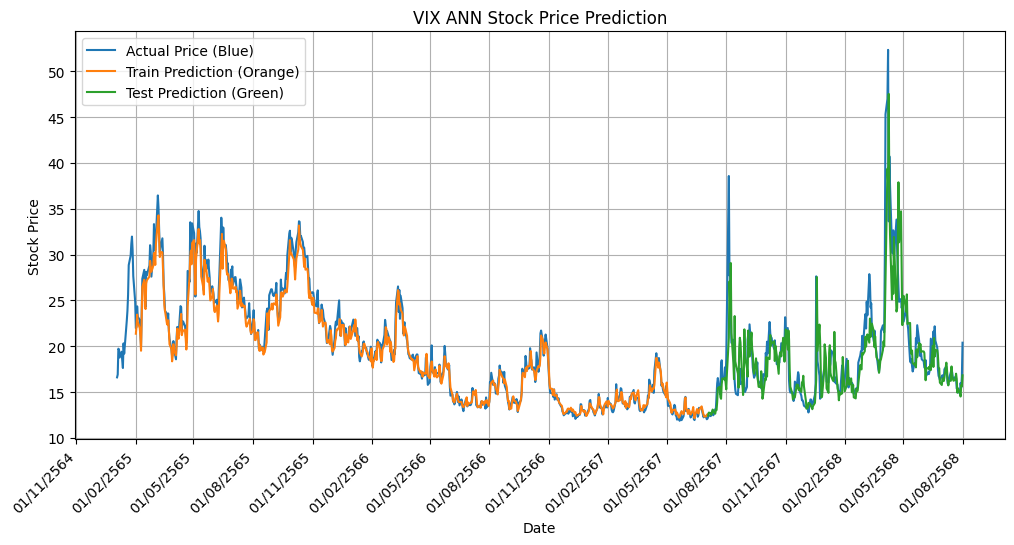

In [ ]:
# --- Configuration ---
look_back = 20  # จำนวนวันย้อนหลังที่ใช้เป็น input

# --- Load and Preprocess Data ---
try:
    df = read_csv(url)
except FileNotFoundError:
    print(f"Error: File not found at {url}.")
    exit()

df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df = df.sort_values(by=df.columns[0], ascending=True).reset_index(drop=True)

# Assuming 'Price' is the 2nd column (index 1)
all_y = df[df.columns[1]].values
dataset=all_y.reshape(-1, 1)

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# แบ่ง train/test (70/30)
train_size = int(len(dataset) * 0.7)
train = dataset[:train_size, :]
test = dataset[train_size - look_back:, :]

# สร้างชุดข้อมูล X, y
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

if testX.shape[0] > 0:
    test_data_available = True
else:
    print("Test dataset too small to create sequences with the given look_back.")
    test_data_available = False

# --- Build ANN Model ---
model = Sequential()
model.add(Input(shape=(look_back,)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))  # Output node เดียวสำหรับพยากรณ์ราคา

model.compile(loss='mse', optimizer='adam')

# --- Train Model ---
print("Training ANN model... This might take a moment.")
start_time = time.time()
model.fit(trainX, trainY, epochs=1000, batch_size=240, verbose=0)
end_time = time.time()
print(f"Model training completed in {end_time - start_time:.2f} seconds.")

# --- Predict ---
trainPredict = model.predict(trainX)
if test_data_available:
    testPredict = model.predict(testX)
else:
    testPredict = np.array([])

# --- Inverse Transform ---
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform(trainY.reshape(-1, 1))
if test_data_available:
    testPredict = scaler.inverse_transform(testPredict)
    testY = scaler.inverse_transform(testY.reshape(-1, 1))
else:
    testY = np.array([[]])

# --- เตรียมวันที่สำหรับ train/test ---
dates = df['Date'].values
dates_train = dates[look_back:len(trainPredict)+look_back]
dates_test = dates[train_size:]

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(dates, scaler.inverse_transform(dataset), label='Actual Price (Blue)')
plt.plot(dates_train, trainPredict, label='Train Prediction (Orange)')
if test_data_available:
    plt.plot(dates_test, testPredict, label='Test Prediction (Green)')
plt.title('VIX ANN Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)

# ---------------------------
# Format วันที่เป็น วัน/เดือน/ปี
# ---------------------------
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)

plt.show()

In [ ]:
print(testPredict[-30:])

[[19.56601 ]
 [18.973572]
 [17.682724]
 [17.591955]
 [16.029846]
 [15.767894]
 [16.494686]
 [16.458925]
 [16.194387]
 [16.575134]
 [18.20391 ]
 [17.419266]
 [16.31716 ]
 [15.728194]
 [16.215736]
 [16.227945]
 [17.790037]
 [16.774809]
 [16.492016]
 [16.229239]
 [16.3358  ]
 [16.999804]
 [16.428566]
 [14.932245]
 [15.397128]
 [14.884147]
 [14.509904]
 [15.758197]
 [15.638231]
 [16.821377]]


In [ ]:
cal_error(trainY[:,0], trainPredict[:,0], testY[:,0], testPredict[:,0])

Train --> RMSE: 0.90, MAE: 0.66, MAPE: 3.11%
Test --> RMSE: 3.20, MAE: 1.90, MAPE: 8.86%


In [ ]:
##################################
##                              ##
##             CNN              ##
##                              ##
##################################

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

In [ ]:
# ---------------------------
# ฟังก์ชันสร้าง window
# ---------------------------
def create_dataset(series, window_size):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0184 - val_loss: 0.0101
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0083
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0074
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - val_loss: 0.0067
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - val_loss: 0.0061
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0057
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0054
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 0.0051
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 0.0050
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - val_loss: 0.0049
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0011 - val_loss: 0.0048
Epoch 12/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0010 - val_lo

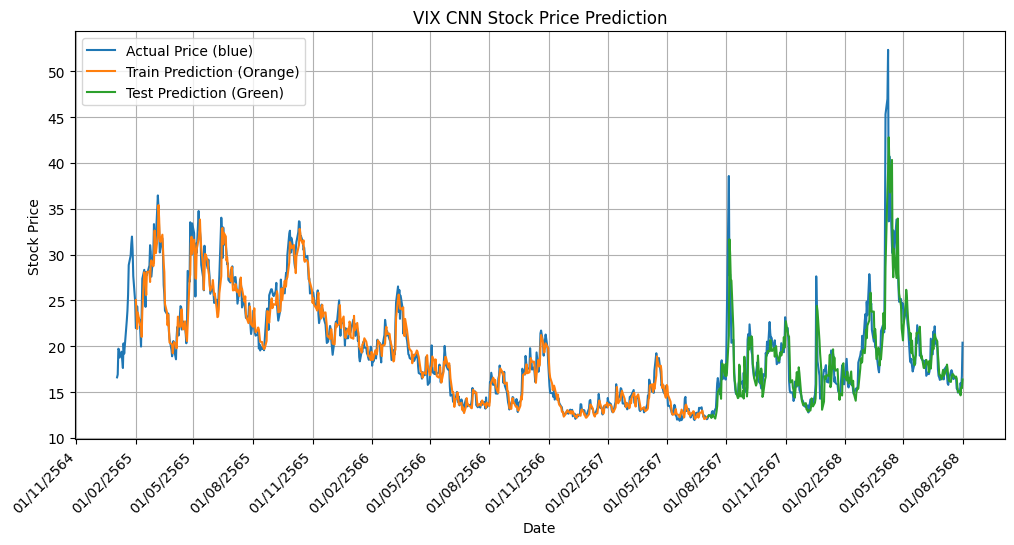

In [ ]:
# ---------------------------
# โหลดชุดข้อมูล
# ---------------------------
df = pd.read_csv(url)
df = df[['Date', 'Price']]  # เลือกเฉพาะวันที่ + ราคาปิด
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')  # เรียงวันที่

# ---------------------------
# Normalize ให้อยู่ระหว่าง 0-1
# ---------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Price'].values.reshape(-1, 1))

# ------------------------------------------------------
# กำหนดขนาด window_size (ใช้ข้อมูลย้อนหลัง 20 วัน)
# ------------------------------------------------------
window_size = 20

# -------------------------------------
# แบ่ง train/test (70/30)
# -------------------------------------
train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - window_size:]

# ---------------------------
# สร้างชุดข้อมูล
# ---------------------------
X_train, y_train = create_dataset(train_data, window_size)
X_test, y_test = create_dataset(test_data, window_size)

# -------------------------------------------
# Reshape ให้เป็น [samples, timesteps, features]
# -------------------------------------------
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ---------------------------
# สร้าง CNN Model
# ---------------------------
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(window_size, 1)), MaxPooling1D(pool_size=2), Flatten(), Dense(32, activation='relu'), Dense(1)])

model.compile(optimizer='adam', loss='mse')

# ---------------------------
# Train Model
# ---------------------------
history = model.fit(X_train, y_train, epochs = 50, batch_size = 8, validation_data=(X_test, y_test))

# ---------------------------
# Evaluate & Predict
# ---------------------------
pred_train = model.predict(X_train)
pred_train = scaler.inverse_transform(pred_train)
actual_train = scaler.inverse_transform(y_train.reshape(-1, 1))

pred_test = model.predict(X_test)
pred_test = scaler.inverse_transform(pred_test)
actual_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---------------------------
# Flatten เพื่อให้ง่ายต่อการ plot
# ---------------------------
pred_train = pred_train.flatten()
actual_train = actual_train.flatten()
pred_test = pred_test.flatten()
actual_test = actual_test.flatten()

# ---------------------------
# ดึงวันที่
# ---------------------------
dates_train = df['Date'].values[window_size:len(pred_train)+look_back]
dates_test = df['Date'].values[train_size:]

# ---------------------------
# Plot
# ---------------------------
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Price'], label = 'Actual Price (blue)')

# ---------------------------
# Plot train pred
# ---------------------------
plt.plot(dates_train, pred_train, label='Train Prediction (Orange)')

# ---------------------------
# Plot test pred
# ---------------------------
plt.plot(dates_test, pred_test, label="Test Prediction (Green)")

plt.legend()
plt.title("VIX CNN Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.grid(True)

# ---------------------------
# Format วันที่เป็น วัน/เดือน/ปี
# ---------------------------
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_thai_date))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval = 3))
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)

# ---------------------------
# แสดงกราฟ
# ---------------------------
plt.show()

In [ ]:
print(pred_test[-30:])

[20.529785 19.111656 18.182522 16.922499 16.880587 16.376583 17.047384
 17.417316 16.764847 16.898478 17.494951 17.99094  17.457645 16.637396
 16.213846 16.100971 16.62063  16.880695 16.961992 16.86474  16.525852
 16.692162 16.47351  15.625924 14.990338 15.140476 14.637569 15.510731
 15.433401 16.366135]


In [ ]:
cal_error(actual_train, pred_train, actual_test, pred_test)

Train --> RMSE: 1.17, MAE: 0.85, MAPE: 4.16%
Test --> RMSE: 2.79, MAE: 1.64, MAPE: 7.75%
